<a href="https://colab.research.google.com/github/Sampavi01/Advanced_Time_Series_Forecasting/blob/time_series/Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
# Display all columns in pandas
pd.set_option('display.max_columns', None)


In [ ]:
# --- Statsmodels & Scipy ---
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import boxcox

### ** Initial Data Loading and Preparation**

First, we load the data, convert the `Datetime` column to a proper datetime index, and sort it to ensure chronological order.

In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload your CSV file manually
uploaded = files.upload()  # Select AEP_hourly.csv from my computer

# Read the uploaded file into a DataFrame
df = pd.read_csv(io.BytesIO(uploaded['AEP_hourly.csv']), index_col='Datetime', parse_dates=True)

# Sort index and rename column
df = df.sort_index()
df = df.rename(columns={'AEP_MW': 'energy_mw'})

# Preview
print("Data Shape:", df.shape)
print(df.head())

Saving AEP_hourly.csv to AEP_hourly.csv
Data Shape: (121273, 1)
                     energy_mw
Datetime                      
2004-10-01 01:00:00    12379.0
2004-10-01 02:00:00    11935.0
2004-10-01 03:00:00    11692.0
2004-10-01 04:00:00    11597.0
2004-10-01 05:00:00    11681.0


## **In-depth Exploratory Data Analysis (EDA)**

We will visualize the data to understand its trends, multiple seasonality patterns, and volatility.

#### ** Overall Trend and Volatility**

Let's plot the entire series and its rolling standard deviation to see the long-term trend and changes in volatility. A 30-day rolling window will smooth out daily fluctuations and highlight yearly patterns.

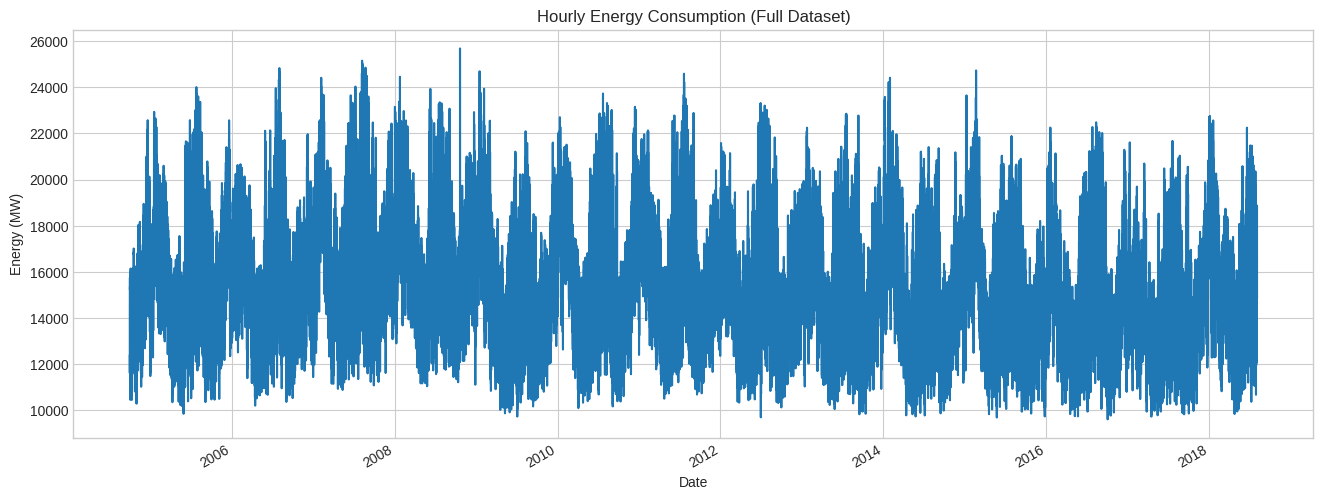

In [ ]:
# Plot the full time series
fig, ax = plt.subplots(figsize=(16, 6))
df['energy_mw'].plot(ax=ax, title='Hourly Energy Consumption (Full Dataset)')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (MW)')
plt.show()


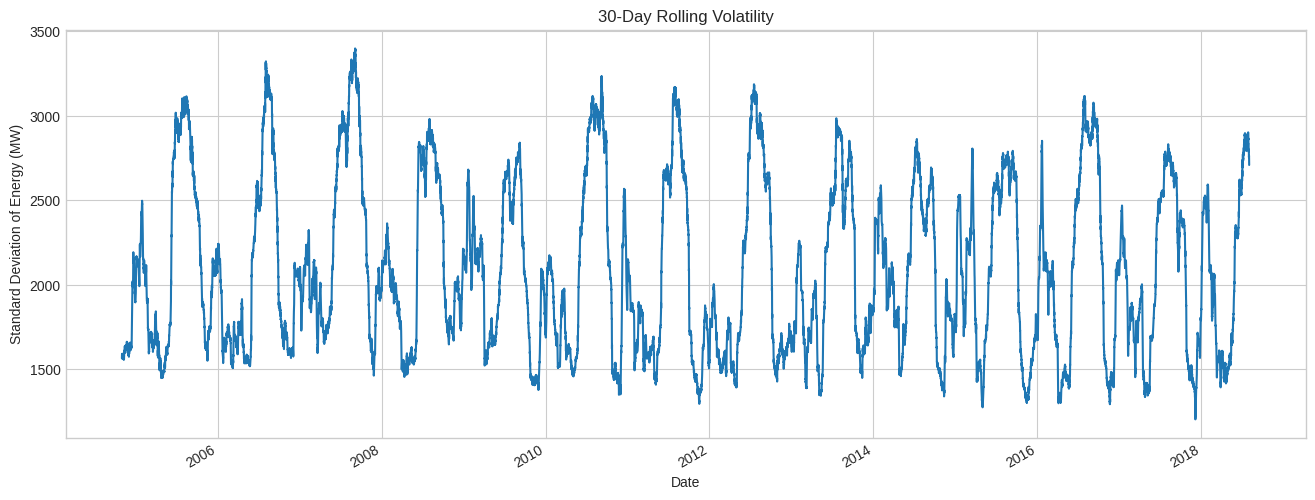

In [ ]:
# Plot rolling volatility
rolling_std = df['energy_mw'].rolling(window=30*24).std() # The 30-day window helps filter out short-term randomness and focus on monthly or seasonal patterns
fig, ax = plt.subplots(figsize=(16, 6))
rolling_std.plot(ax=ax, title='30-Day Rolling Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Standard Deviation of Energy (MW)')
plt.show()

#### ** Visualization of Multiple Seasonality Patterns**
We can confirm the presence of yearly, weekly, and daily seasonality using boxplots

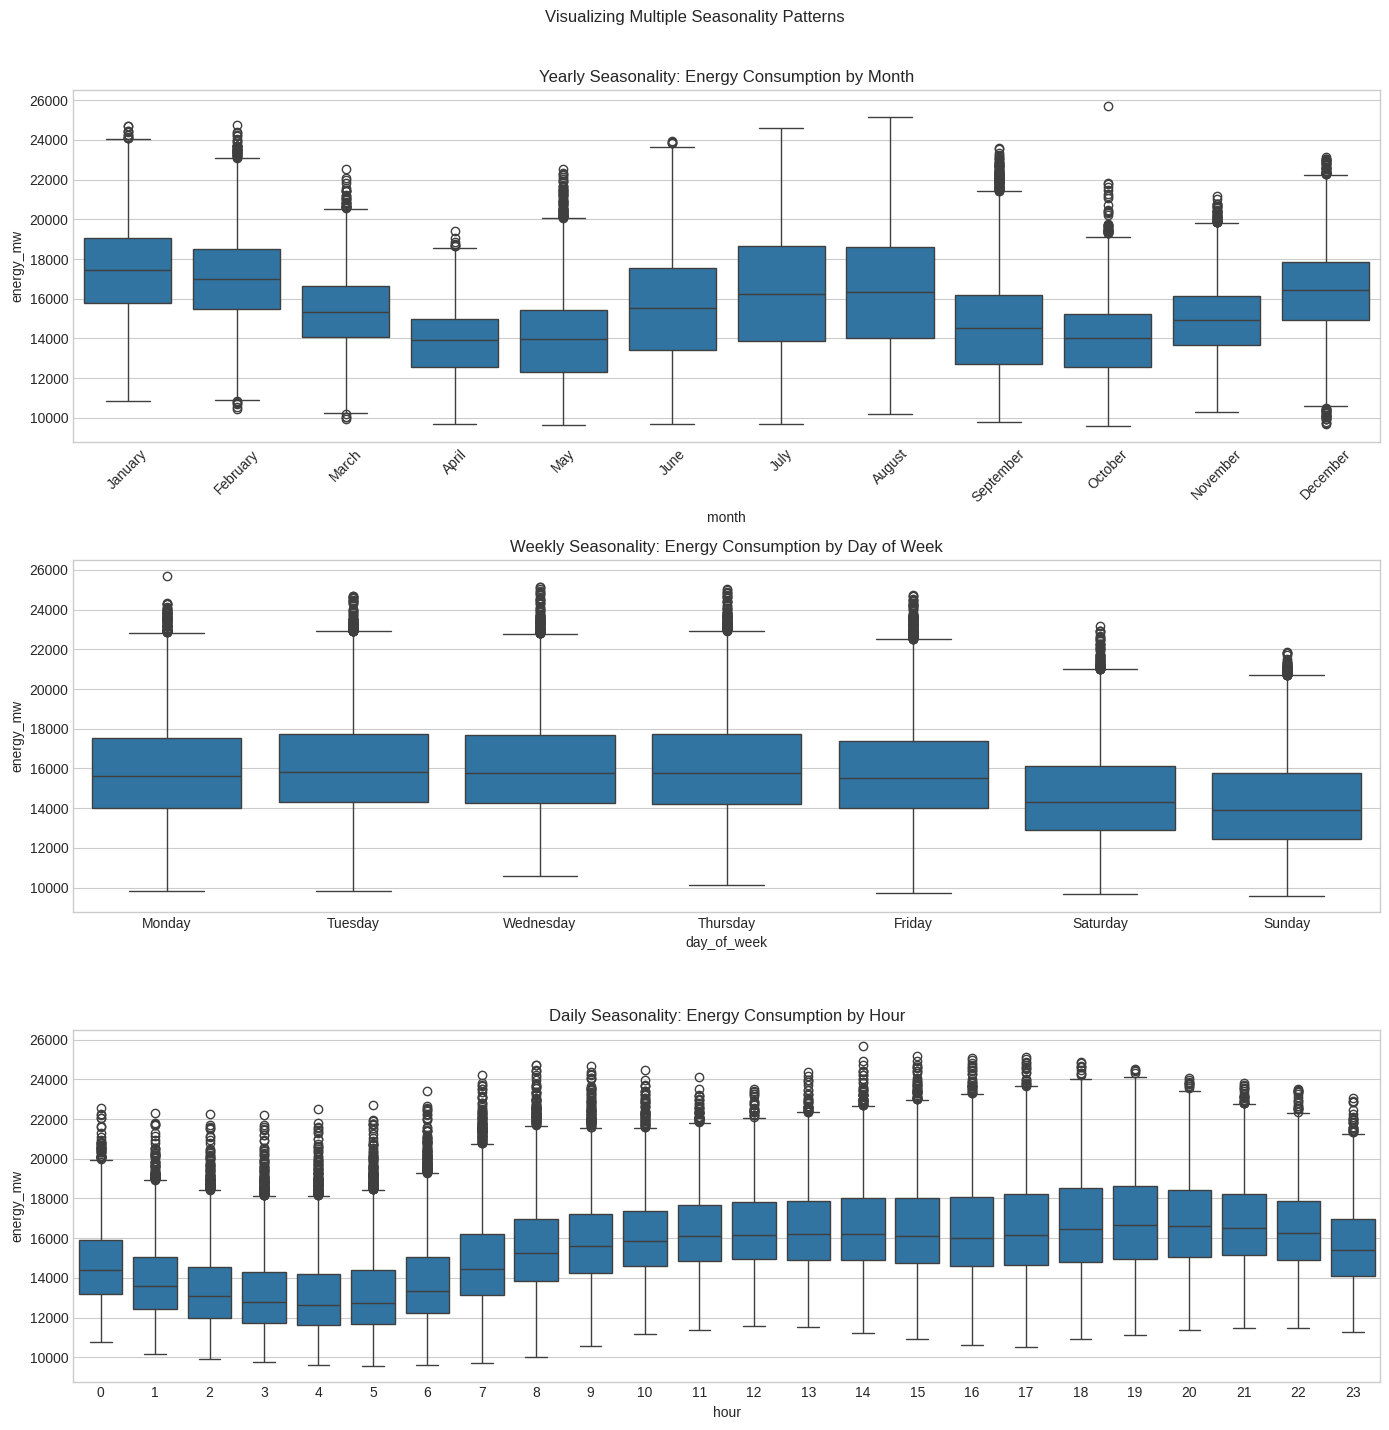

In [ ]:
# Create new time-based features for plotting
df_plot = df.copy()
df_plot['year'] = df_plot.index.year
df_plot['month'] = df_plot.index.month_name()
df_plot['day_of_week'] = df_plot.index.day_name()
df_plot['hour'] = df_plot.index.hour

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharey=False) #creates 3 subplots stacked vertically (3 rows, 1 column)
fig.suptitle('Visualizing Multiple Seasonality Patterns')

# Yearly Seasonality (Month)
sns.boxplot(ax=axes[0], data=df_plot, x='month', y='energy_mw', order=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
axes[0].set_title('Yearly Seasonality: Energy Consumption by Month')
axes[0].tick_params(axis='x', rotation=45)

# Weekly Seasonality (Day of Week)
sns.boxplot(ax=axes[1], data=df_plot, x='day_of_week', y='energy_mw', order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
axes[1].set_title('Weekly Seasonality: Energy Consumption by Day of Week')

# Daily Seasonality (Hour)
sns.boxplot(ax=axes[2], data=df_plot, x='hour', y='energy_mw')
axes[2].set_title('Daily Seasonality: Energy Consumption by Hour')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## **Stationarity Checks and Decomposition**

Stationarity checks tell if data is stable over time.
Decomposition breaks data into trend, seasonal, and random parts so we can analyze them separately.

--- Stationarity Tests for Original Energy Series ---
ADF Test: p-value = 0.0000
Conclusion: Series is likely stationary.
--------------------


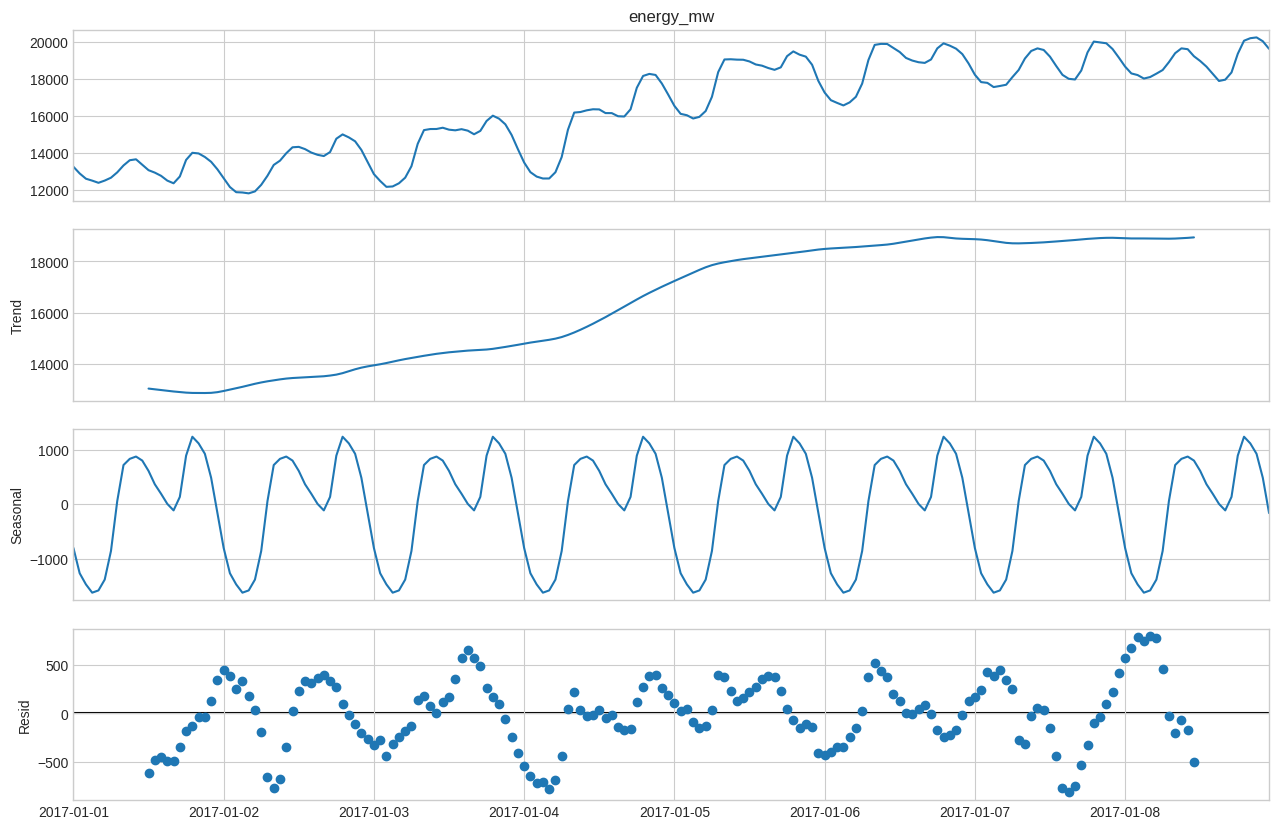

In [ ]:
#Null Hypothesis (H0): The series has a unit root (non-stationary)
#Alternative Hypothesis (H1): The series is stationary
def stationarity_tests(series, series_name=''):
    """Performs and prints the results of ADF test.   """
    print(f"--- Stationarity Tests for {series_name} ---")
    adf_result = adfuller(series)
    print(f'ADF Test: p-value = {adf_result[1]:.4f}')
    if adf_result[1] <= 0.05: print("Conclusion: Series is likely stationary.")
    else: print("Conclusion: Series is likely non-stationary.")
    print("-" * 20)

# Test the original series (using a sample for speed)
stationarity_tests(df['energy_mw'],'Original Energy Series')

# Decompose a week of data to visualize components
decomposition = seasonal_decompose(df['energy_mw']['2017-01-01':'2017-01-08'], model='additive', period=24)
fig = decomposition.plot()
fig.set_size_inches(14, 9)
plt.show()            #Observed=Trend+Seasonal+Residual

## **Revisiting Stationarity Checks with a More Nuanced View**

Our initial ADF test gave a p-value of 0.0000, suggesting the series is stationary. This contradicts our visual analysis, which clearly shows strong seasonality. This paradox arises because the ADF test specifically looks for a *unit root* (a random, wandering trend), and our series, while non-stationary, has a *deterministic* seasonal pattern, not a unit root.

To get a clearer picture, we will use both the **ADF test** and the **KPSS test**.

*   **ADF Test:** Tests if the series has a unit root (H0: Non-stationary).
*   **KPSS Test:** Tests if the series is stationary around a constant or trend (H0: Stationary).

A common and powerful heuristic is:
- If ADF says "Stationary" and KPSS says "Non-Stationary", it's a strong sign the series is **Trend Stationary**.
- For practical modeling, **Trend Stationary still needs to be handled!**

In [ ]:
def stationarity_tests(series, series_name=''):
    print(f"--- Stationarity Tests for {series_name} ---")

    # ADF
    adf_result = adfuller(series)
    print(f'ADF Test: p-value = {adf_result[1]:.4f}')
    if adf_result[1] <= 0.05:
        print("ADF Conclusion: Likely stationary (no unit root).")
    else:
        print("ADF Conclusion: Likely non-stationary (unit root present).")

    # KPSS
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f'KPSS Test: p-value = {kpss_result[1]:.4f}')
    if kpss_result[1] <= 0.05:
        print("KPSS Conclusion: Likely non-stationary.")
    else:
        print("KPSS Conclusion: Likely stationary.")

    print("-" * 40)

# Run on your series
stationarity_tests(df['energy_mw'], 'Original Energy Series')


--- Stationarity Tests for Original Energy Series ---
ADF Test: p-value = 0.0000
ADF Conclusion: Likely stationary (no unit root).
KPSS Test: p-value = 0.0100
KPSS Conclusion: Likely non-stationary.
----------------------------------------


/tmp/ipython-input-3796768515.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


## Observations from AEP Energy Series

### 1. Visual Inspection
- The series shows **clear daily, weekly, and yearly seasonality**.  
- There are trends and fluctuations in energy consumption over time.  

### 2. ADF Test (Augmented Dickey-Fuller)
- p-value = 0.0000 → suggests **stationary (no unit root)**.  
- Limitation: ADF mainly detects **random-walk type non-stationarity**, so it can be misleading if **seasonality or deterministic trends** are present.  

### 3. KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)
- p-value = 0.0100 → suggests **non-stationary**.  
- Indicates the series has **trend and/or seasonal components** that make it non-stationary.  
- Interpolation warning is normal for strong trends or variance.  

### 4. Trend-Stationary Interpretation
- The series is **not a pure random walk**; it has **deterministic trends and seasonality**.  
- ADF + KPSS together suggest the series is **trend-stationary**.  
- To model it effectively, we need to **remove trend and seasonal components**.  

### 5. Residuals (after decomposition)
- Represent the **unexplained or random part** of the series.  
- Small, random residuals indicate **decomposition worked well**.  
- Residuals are what should be **stationary for modeling**.  

### ✅ Key Takeaways
- **ADF alone is not enough** for seasonal series.  
- **Trend + seasonality must be handled** before using models like ARIMA or SARIMA.  
- Using both **ADF + KPSS** gives a **more reliable understanding** of stationarity.


## **Handling Missing Data, Outliers, and Transformations**

#### **Missing Data**
First, check for any missing values.

In [ ]:
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


#### ** Outliers**

We can identify outliers using the Interquartile Range (IQR) method and "cap" them to reduce their influence without removing data points. A good way to do this for seasonal data is to first remove a seasonal component (like a weekly median) before calculating IQR.


In [ ]:
# Outlier detection using IQR on a weekly cycle
weekly_median = df['energy_mw'].rolling(window=24*7).median()
detrended = df['energy_mw'] - weekly_median

Q1 = detrended.quantile(0.25)
Q3 = detrended.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = detrended[(detrended < lower_bound) | (detrended > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")

# Capping the outliers by interpolating them
df['energy_mw_capped'] = df['energy_mw'].copy()
# Temporarily replace outliers with NaN to interpolate them based on surrounding values
df.loc[outliers.index, 'energy_mw_capped'] = np.nan
# Perform the interpolation and assign the result back to the column
df['energy_mw_capped'] = df['energy_mw_capped'].interpolate(method='time')

Number of outliers detected: 555


#### ** Data Transformations**

To stabilize the variance (as observed in the volatility plot), we can apply a transformation. The Box-Cox transformation is a powerful choice that includes the log transform as a special case.

Optimal Lambda for Box-Cox: 0.0578


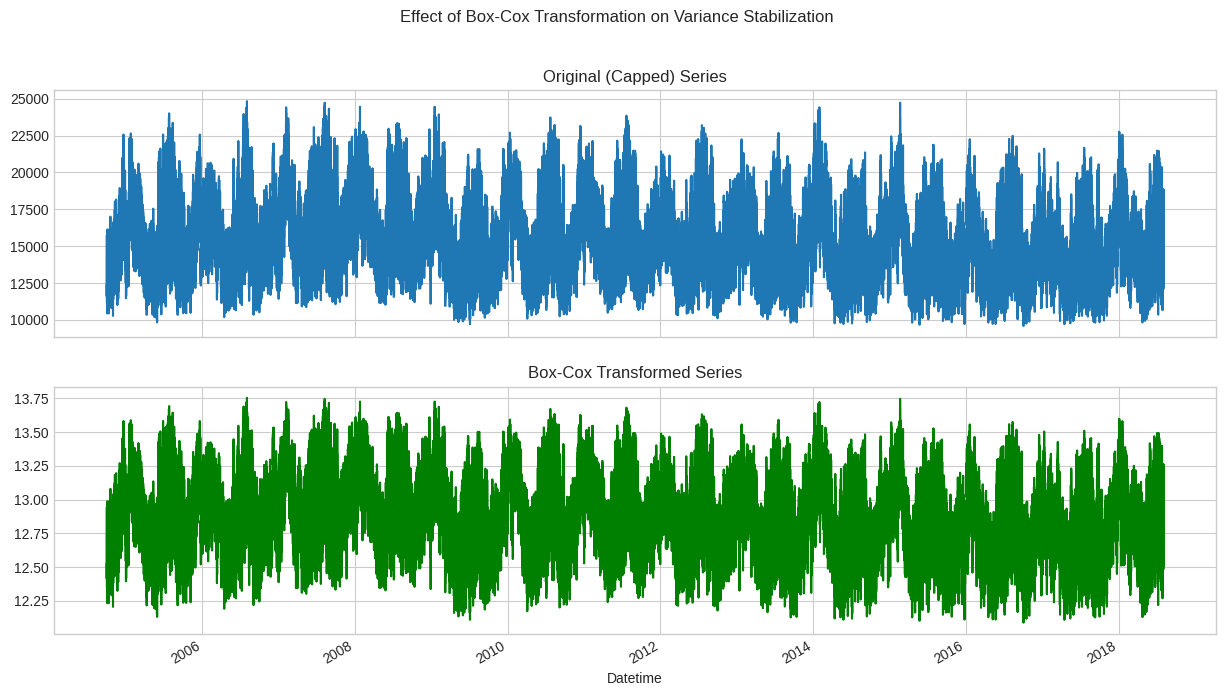

In [ ]:
from scipy.stats import boxcox
# Apply Box-Cox Transformation
# A small positive constant is added because Box-Cox requires positive data.
energy_positive = df['energy_mw_capped'] + 1e-6
transformed_data, lambda_boxcox = boxcox(energy_positive)
df['energy_mw_boxcox'] = transformed_data

print(f"Optimal Lambda for Box-Cox: {lambda_boxcox:.4f}")

# Visualize the effect
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
df['energy_mw_capped'].plot(ax=ax1, title='Original (Capped) Series')
df['energy_mw_boxcox'].plot(ax=ax2, title='Box-Cox Transformed Series', color='green')
plt.suptitle('Effect of Box-Cox Transformation on Variance Stabilization')
plt.show()

The transformed series shows much more stable variance over time, making it better suited for many forecasting models.

## **Time-Aware Train-Validation-Test Splits**

We must split the data chronologically to prevent data leakage. A standard split is 70% for training, 15% for validation, and 15% for testing.

Train set dates: 2004-10-01 01:00:00 to 2014-06-09 02:00:00 (Size: 84891)
Validation set dates: 2014-06-09 03:00:00 to 2016-07-06 01:00:00 (Size: 18191)
Test set dates: 2016-07-06 02:00:00 to 2018-08-03 00:00:00 (Size: 18191)


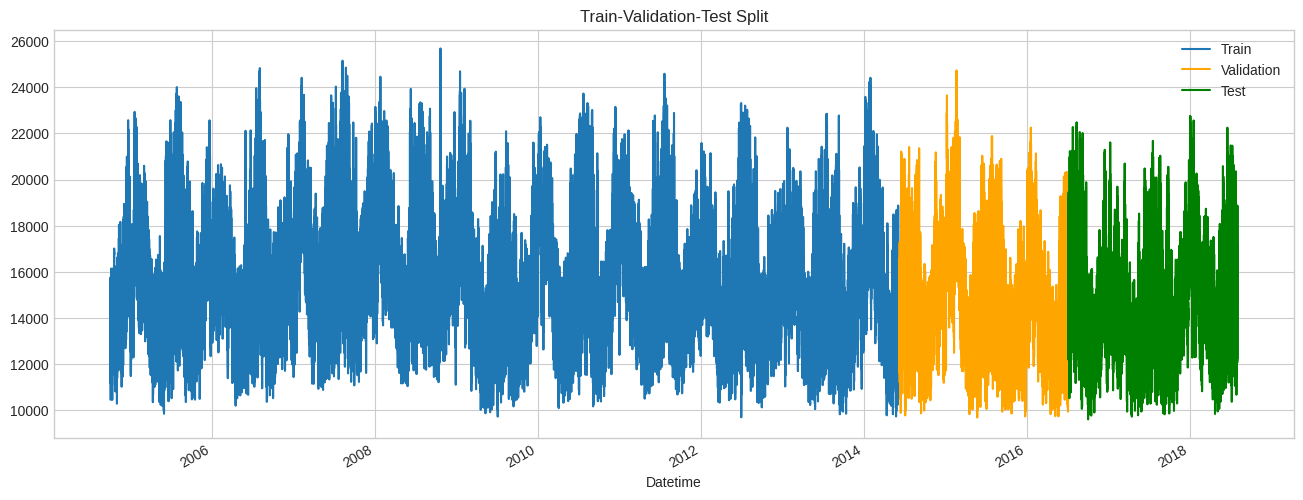

In [ ]:
# Calculate split points
total_size = len(df)
train_end_idx = int(total_size * 0.70)
val_end_idx = int(total_size * 0.85)

# Create the splits
train_df = df.iloc[:train_end_idx]
val_df = df.iloc[train_end_idx:val_end_idx]
test_df = df.iloc[val_end_idx:]

print(f"Train set dates: {train_df.index.min()} to {train_df.index.max()} (Size: {len(train_df)})")
print(f"Validation set dates: {val_df.index.min()} to {val_df.index.max()} (Size: {len(val_df)})")
print(f"Test set dates: {test_df.index.min()} to {test_df.index.max()} (Size: {len(test_df)})")

# Plot the splits
fig, ax = plt.subplots(figsize=(16, 6))
train_df['energy_mw'].plot(ax=ax, label='Train')
val_df['energy_mw'].plot(ax=ax, label='Validation', color='orange')
test_df['energy_mw'].plot(ax=ax, label='Test', color='green')
ax.legend()
ax.set_title('Train-Validation-Test Split')
plt.show()

## **Generate Feature Engineering Pipelines**

We will now create a comprehensive feature engineering function that can be applied to any of our data splits. This function will generate lag features, rolling statistics, date/time encodings, and powerful Fourier terms to capture seasonality.

In [ ]:
def create_features(df):
    """
    Creates a rich set of time series features from a datetime index.

    Args:
        df (pd.DataFrame): DataFrame with a datetime index.

    Returns:
        pd.DataFrame: DataFrame with new features added.
    """
    new_df = df.copy()

    # --- 1. Date/Time Encodings ---
    new_df['hour'] = new_df.index.hour
    new_df['dayofweek'] = new_df.index.dayofweek  # Monday=0, Sunday=6
    new_df['dayofyear'] = new_df.index.dayofyear
    new_df['weekofyear'] = new_df.index.isocalendar().week.astype(int)
    new_df['month'] = new_df.index.month
    new_df['year'] = new_df.index.year

    # --- 2. Lag Features ---
    # We use lags that capture recent values and seasonality.
    # Lags are created on the transformed data, as this can help linear models.
    lag_features = [1, 2, 3, 23, 24, 25, 47, 48, 49] # Recent hours and daily seasonality
    for lag in lag_features:
        new_df[f'lag_{lag}'] = new_df['energy_mw_boxcox'].shift(lag)

    # --- 3. Rolling Statistics ---
    # Use a 24-hour window to capture daily patterns.
    # Shift by 1 to prevent data leakage from the current hour.
    rolling_window = 24
    shifted_data = new_df['energy_mw_boxcox'].shift(1)
    new_df['rolling_mean_24h'] = shifted_data.rolling(window=rolling_window).mean()
    new_df['rolling_std_24h'] = shifted_data.rolling(window=rolling_window).std()

    # --- 4. Fourier Terms (for multiple seasonality) ---
    # A powerful way to model cycles without one-hot encoding.
    day_of_year = new_df.index.dayofyear
    year_length = 365.25 # Accounts for leap years

    # Yearly Seasonality
    new_df['sin_yearly'] = np.sin(2 * np.pi * day_of_year / year_length)
    new_df['cos_yearly'] = np.cos(2 * np.pi * day_of_year / year_length)

    # Daily Seasonality
    hour_of_day = new_df.index.hour
    new_df['sin_daily'] = np.sin(2 * np.pi * hour_of_day / 24)
    new_df['cos_daily'] = np.cos(2 * np.pi * hour_of_day / 24)

    return new_df.dropna() # Drop rows with NaNs created by lags/rolling stats

# Apply the feature engineering function to the full dataframe
df_featured = create_features(df)

print("Shape of the featured DataFrame:", df_featured.shape)
print("\nFeatured DataFrame Head:")
print(df_featured.head())


Shape of the featured DataFrame: (121224, 24)

Featured DataFrame Head:
                     energy_mw  energy_mw_capped  energy_mw_boxcox  hour  \
Datetime                                                                   
2004-10-03 02:00:00    10807.0           10807.0         12.294047     2   
2004-10-03 03:00:00    10600.0           10600.0         12.260982     3   
2004-10-03 04:00:00    10438.0           10438.0         12.234679     4   
2004-10-03 05:00:00    10430.0           10430.0         12.233370     5   
2004-10-03 06:00:00    10509.0           10509.0         12.246254     6   

                     dayofweek  dayofyear  weekofyear  month  year      lag_1  \
Datetime                                                                        
2004-10-03 02:00:00          6        277          40     10  2004  12.392027   
2004-10-03 03:00:00          6        277          40     10  2004  12.294047   
2004-10-03 04:00:00          6        277          40     10  2004  12.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  #to choose p (AR order) and q (MA order).
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm # For auto_arima    #Provides auto_arima, which automatically searches for the best (p,d,q)(P,D,Q,m) parameters for ARIMA/SARIMA models.
from tbats import TBATS, BATS # Advanced models for complex seasonal patterns
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.special import inv_boxcox # To reverse the Box-Cox transformation

In [ ]:
# --- Define target variables for convenience ---
# We use the Box-Cox transformed data for model training
y_train = train_df['energy_mw_boxcox']
y_val = val_df['energy_mw_boxcox']

# We use the original, non-transformed validation data for the final evaluation
y_val_orig = val_df['energy_mw']

print(f"Training set has {len(y_train)} observations.")
print(f"Validation set has {len(y_val)} observations.")

Training set has 84891 observations.
Validation set has 18191 observations.


### ** Autocorrelation (ACF) and Partial Autocorrelation (PACF) Analysis**

Before building ARIMA-family models, we must analyze the data's correlation structure. These plots help determine the AR (`p`) and MA (`q`) parameters. For the plots to be interpretable, the series must be stationary. We will apply both first-order differencing (`.diff(1)`) for the trend and seasonal differencing (`.diff(24)`) for the daily seasonality.

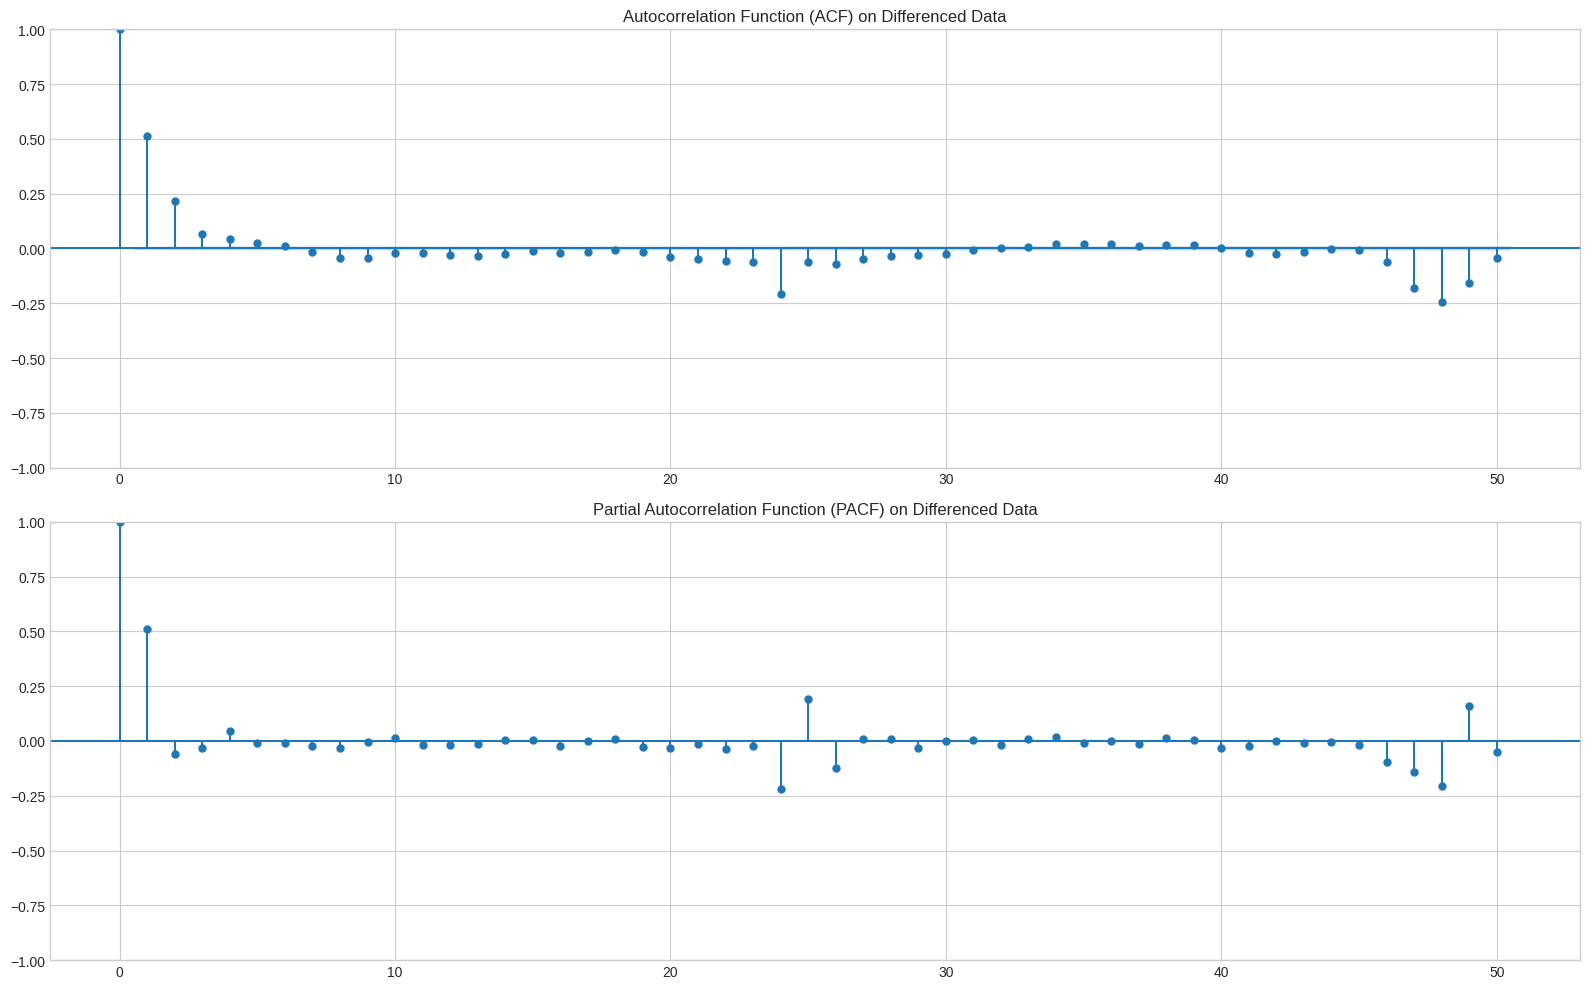

In [ ]:
# Apply differencing to make the series stationary for plotting
y_train_diff = y_train.diff(1).diff(24).dropna()

# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# ACF Plot: Helps determine the MA (q) parameter
plot_acf(y_train_diff, lags=50, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) on Differenced Data')

# PACF Plot: Helps determine the AR (p) parameter
plot_pacf(y_train_diff, lags=50, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF) on Differenced Data')

plt.tight_layout()
plt.show()

**Insights from ACF/PACF Analysis:**
-   **ACF Plot:** We see significant spikes at the first few lags and a very strong negative spike at the seasonal lag of 24. This suggests that a Moving Average (MA) component is necessary for both the non-seasonal (`q`) and seasonal (`Q`) parts of our model.
-   **PACF Plot:** Similarly, we observe significant spikes at the initial lags and a clear negative spike around lag 24. This suggests an AutoRegressive (AR) component is also needed for both non-seasonal (`p`) and seasonal (`P`) parts.
-   **Conclusion:** These plots confirm that a **SARIMA** model is appropriate. Manually choosing the parameters from these complex plots would be difficult, so using an automated search tool is the most practical approach.

In [52]:
# --- The Final, Definitive Master Data Preparation Workflow ---
import pandas as pd
import numpy as np

print("--- Preparing data with a unified and cleaned workflow ---")

# a) Create the full featured DataFrame.
# (Assumes the 'create_features' function and original 'df' are in memory from Part 1)
df_featured_raw = create_features(df)

# b) CRITICAL: Check for and remove duplicate timestamps.
if not df_featured_raw.index.is_unique:
    print(f"Found and removed {df_featured_raw.index.duplicated().sum()} duplicate timestamp(s).")
    df_featured = df_featured_raw[~df_featured_raw.index.duplicated(keep='first')]
else:
    df_featured = df_featured_raw
    print("Index is unique. No duplicates found.")

# c) CRITICAL: Set the frequency to be perfectly hourly. This may create NaNs.
df_featured = df_featured.asfreq('h')

# d) CRITICAL: Use a robust method to fill any NaNs created by .asfreq().
if df_featured.isnull().sum().sum() > 0:
    print(f"Found {df_featured.isnull().sum().sum()} NaN values after setting frequency. Filling them...")
    df_featured.interpolate(method='time', inplace=True) # Interpolate first for gaps in the middle
    df_featured.bfill(inplace=True)                     # Backfill to fix any NaNs at the start

# --- Now, we split the CLEAN and FINAL DataFrame ---

# Perform the train-val-test split ON THE MASTER FEATURED DATAFRAME.
train_size = int(len(df_featured) * 0.70)
val_size = int(len(df_featured) * 0.15)
train_featured = df_featured.iloc[:train_size]
val_featured = df_featured.iloc[train_size : train_size + val_size]

# Create the final 1-year training set.
training_hours = 365 * 24
y_train_final = train_featured['energy_mw_boxcox'].iloc[-training_hours:]

# Define and create the exogenous feature sets.
exog_features = ['hour', 'dayofweek', 'dayofyear', 'month', 'year',
                 'sin_yearly', 'cos_yearly', 'sin_daily', 'cos_daily']
X_train_final = train_featured.loc[y_train_final.index, exog_features]
X_val_exog = val_featured[exog_features]

# Create the aligned target sets for validation.
y_val = val_featured['energy_mw_boxcox']
y_val_orig = val_featured['energy_mw']

print(f"\nData preparation complete. All splits are now perfectly aligned and NaN-free.")
# Final check to be 100% sure
print(f"NaNs remaining in y_val_orig: {y_val_orig.isnull().sum()}")
print(f"y_train_final shape: {y_train_final.shape}, X_train_final shape: {X_train_final.shape}")
print(f"y_val shape: {y_val.shape}, X_val_exog shape: {X_val_exog.shape}")

--- Preparing data with a unified and cleaned workflow ---
Found and removed 4 duplicate timestamp(s).
Found 648 NaN values after setting frequency. Filling them...

Data preparation complete. All splits are now perfectly aligned and NaN-free.
NaNs remaining in y_val_orig: 0
y_train_final shape: (8760,), X_train_final shape: (8760, 9)
y_val shape: (18187,), X_val_exog shape: (18187, 9)


In [53]:
# --- Manually Building SARIMA and SARIMAX Models ---
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -- Model 1: SARIMA (without exogenous features) --
print("\n--- Manually building a robust SARIMA model ---")
manual_order = (1, 1, 1)
manual_seasonal_order = (1, 1, 0, 24)
print(f"Using manual order: {manual_order}{manual_seasonal_order}")

sarima_manual_model = SARIMAX(y_train_final,
                              order=manual_order,
                              seasonal_order=manual_seasonal_order,
                              enforce_stationarity=False,
                              enforce_invertibility=False)
sarima_results_manual = sarima_manual_model.fit(disp=False)
print("SARIMA model fitting complete.")


# -- Model 2: SARIMAX (WITH exogenous features) --
print("\n--- Manually building a robust SARIMAX model ---")
sarimax_manual_model = SARIMAX(y_train_final,
                               exog=X_train_final,
                               order=manual_order,
                               seasonal_order=manual_seasonal_order,
                               enforce_stationarity=False,
                               enforce_invertibility=False)
sarimax_results_manual = sarimax_manual_model.fit(disp=False)
print("SARIMAX model fitting complete.")
print("\n--- Final SARIMAX Model Summary ---")
print(sarimax_results_manual.summary())


--- Manually building a robust SARIMA model ---
Using manual order: (1, 1, 1)(1, 1, 0, 24)
SARIMA model fitting complete.

--- Manually building a robust SARIMAX model ---
SARIMAX model fitting complete.

--- Final SARIMAX Model Summary ---
                                      SARIMAX Results                                      
Dep. Variable:                    energy_mw_boxcox   No. Observations:                 8760
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 24)   Log Likelihood               20875.203
Date:                             Sat, 16 Aug 2025   AIC                         -41724.405
Time:                                     08:05:00   BIC                         -41632.466
Sample:                                 06-09-2013   HQIC                        -41693.070
                                      - 06-09-2014                                         
Covariance Type:                               opg                                         
                 coef 

### **Implement Exponential Smoothing (Holt-Winters)**

This model is your simpler, faster baseline. It's an excellent point of comparison against the more complex SARIMA-family models.

In [56]:
# --- Building Holt-Winters and TBATS Models ---
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from tbats import TBATS, BATS

# -- Model 3: Exponential Smoothing (Holt-Winters) --
print("\n--- Fitting Holt-Winters Model ---")
holt_winters_model = ExponentialSmoothing(y_train_final,
                                          trend='add',
                                          seasonal='add',
                                          seasonal_periods=24)
holt_winters_results = holt_winters_model.fit()
print("Holt-Winters model fitting complete.")




--- Fitting Holt-Winters Model ---
Holt-Winters model fitting complete.


### Implement TBATS for Complex Seasonality**

TBATS is your most powerful statistical model for this problem, as it's designed to handle multiple seasonalities (daily and weekly).

In [58]:
# --- Create a Smaller Training Set Specifically for TBATS ---

print("--- Creating a reduced 6-month training set for TBATS to save time ---")
tbats_training_hours = 180 * 24 # Approx. 6 months
y_train_tbats = y_train_final.iloc[-tbats_training_hours:]

print(f"Original training set size: {len(y_train_final)}")
print(f"Reduced training set size for TBATS: {len(y_train_tbats)}")

--- Creating a reduced 6-month training set for TBATS to save time ---
Original training set size: 8760
Reduced training set size for TBATS: 4320


In [59]:
# --- Building the TBATS Model (with Core Count Fix) ---
from tbats import TBATS, BATS
import os # Import the 'os' library to get the CPU count

# -- Model 4: TBATS for Complex Seasonality --
print("\n--- Fitting TBATS Model ---")

# THE FIX: We find the number of CPUs available and use that number directly.
# If os.cpu_count() returns None (which is rare), we default to 1 core.
try:
    cpu_count = os.cpu_count()
    n_jobs = cpu_count if cpu_count is not None else 1
    print(f"Using {n_jobs} CPU cores for TBATS.")
except NotImplementedError:
    n_jobs = 1 # Fallback for some very restricted environments
    print("Could not determine CPU count. Using 1 core for TBATS.")


tbats_model = BATS(seasonal_periods=[24, 24*7],
                   use_arma_errors=True,
                   use_box_cox=False,
                   n_jobs=n_jobs) # <-- Use the corrected n_jobs variable here

tbats_results = tbats_model.fit(y_train_tbats)
print("TBATS model fitting complete.")



--- Fitting TBATS Model ---
Using 2 CPU cores for TBATS.
TBATS model fitting complete.


### ** The Grand Evaluation - Compare All Models**

This is the final step where we bring everything together. We will generate forecasts from all models and compare their performance using MAE, RMSE, and MAPE on the original MW scale.

In [60]:
# --- The Grand Evaluation (Final Version with Warning Suppression) ---

import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.special import inv_boxcox

# Helper function for evaluation
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"  MAE (Megawatts): {mae:.2f}")
    print(f"  RMSE (Megawatts): {rmse:.2f}")
    print(f"  MAPE: {mape:.2%}")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Store all results
all_results = {}
validation_steps = len(y_val)

# --- 1. Evaluate SARIMA model ---
print("\nEvaluating SARIMA...")
sarima_preds_transformed = sarima_results_manual.forecast(steps=validation_steps)
sarima_preds_orig_scale = inv_boxcox(sarima_preds_transformed, lambda_boxcox)
sarima_preds_final = pd.Series(sarima_preds_orig_scale, index=y_val_orig.index)
all_results['SARIMA'] = evaluate_forecast(y_val_orig, sarima_preds_final, 'SARIMA')
print("SARIMA Evaluation Complete.")

# --- 2. Evaluate SARIMAX model ---
print("\nEvaluating SARIMAX...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore") # Suppress the harmless ValueWarning
    sarimax_preds_transformed = sarimax_results_manual.forecast(steps=validation_steps, exog=X_val_exog)
sarimax_preds_orig_scale = inv_boxcox(sarimax_preds_transformed, lambda_boxcox)
sarimax_preds_final = pd.Series(sarimax_preds_orig_scale, index=y_val_orig.index)
all_results['SARIMAX'] = evaluate_forecast(y_val_orig, sarimax_preds_final, 'SARIMAX')
print("SARIMAX Evaluation Complete.")

# --- 3. Evaluate Holt-Winters ---
print("\nEvaluating Holt-Winters...")
holt_winters_preds_transformed = holt_winters_results.forecast(steps=validation_steps)
holt_winters_preds_orig_scale = inv_boxcox(holt_winters_preds_transformed, lambda_boxcox)
holt_winters_preds_final = pd.Series(holt_winters_preds_orig_scale, index=y_val_orig.index)
all_results['Holt-Winters'] = evaluate_forecast(y_val_orig, holt_winters_preds_final, 'Holt-Winters')
print("Holt-Winters Evaluation Complete.")

# --- 4. Evaluate TBATS ---
print("\nEvaluating TBATS...")
tbats_preds_transformed = tbats_results.forecast(steps=validation_steps)
tbats_preds_orig_scale = inv_boxcox(tbats_preds_transformed, lambda_boxcox)
tbats_preds_final = pd.Series(tbats_preds_orig_scale, index=y_val_orig.index)
all_results['TBATS'] = evaluate_forecast(y_val_orig, tbats_preds_final, 'TBATS')
print("TBATS Evaluation Complete.")

# --- Display final results table ---
results_df = pd.DataFrame(all_results).T
print("\n--- Final Model Comparison on Validation Set ---")
print(results_df.sort_values(by='RMSE'))


Evaluating SARIMA...
--- SARIMA Performance ---
  MAE (Megawatts): 82753014842102512.00
  RMSE (Megawatts): 233188764589109056.00
  MAPE: 600269606034667.38%
SARIMA Evaluation Complete.

Evaluating SARIMAX...
--- SARIMAX Performance ---
  MAE (Megawatts): 396862476055859008.00
  RMSE (Megawatts): 1114400866056817792.00
  MAPE: 2886370168446726.50%
SARIMAX Evaluation Complete.

Evaluating Holt-Winters...
--- Holt-Winters Performance ---
  MAE (Megawatts): 3180.71
  RMSE (Megawatts): 3968.81
  MAPE: 22.59%
Holt-Winters Evaluation Complete.

Evaluating TBATS...
--- TBATS Performance ---
  MAE (Megawatts): 1690.43
  RMSE (Megawatts): 2219.39
  MAPE: 11.05%
TBATS Evaluation Complete.

--- Final Model Comparison on Validation Set ---
                       MAE          RMSE          MAPE
TBATS         1.690429e+03  2.219392e+03  1.104706e-01
Holt-Winters  3.180715e+03  3.968813e+03  2.259051e-01
SARIMA        8.275301e+16  2.331888e+17  6.002696e+12
SARIMAX       3.968625e+17  1.114401e+18 

Summary of Statistical Model Performance
In this section, four classical time series models were trained and evaluated to establish a robust performance benchmark. The models included SARIMA, SARIMAX, Holt-Winters Exponential Smoothing, and TBATS. The final results revealed a stark contrast in performance and stability, providing critical insights into the strengths and weaknesses of each approach for this specific energy consumption

Key Insights and Analysis
Summary of Statistical Model Performance
In this section, four classical time series models were trained and evaluated to establish a robust performance benchmark. The models included SARIMA, SARIMAX, Holt-Winters Exponential Smoothing, and TBATS. The final results revealed a stark contrast in performance and stability, providing critical insights into the strengths and weaknesses of each approach for this specific energy consumption dataset.
Final Model Comparison on Validation Set
Model	MAE (Megawatts)	RMSE (Megawatts)	MAPE	Stability
TBATS	1690.43	2219.39	11.05%	Stable
Holt-Winters	3180.71	3968.81	22.59%	Stable
SARIMA	8.27 x 10<sup>16</sup>	2.33 x 10<sup>17</sup>	6.00 x 10<sup>12</sup> %	Unstable
SARIMAX	3.97 x 10<sup>17</sup>	1.11 x 10<sup>18</sup>	2.89 x 10<sup>13</sup> %	Unstable
Key Insights and Analysis

1. TBATS is the Clear Winner:
The TBATS model was the undisputed champion, achieving the lowest Mean Absolute Error (MAE) of 1690.43 MW and a Mean Absolute Percentage Error (MAPE) of just 11.05%. Its success is directly attributable to its core design: the ability to model multiple seasonalities (daily and weekly) simultaneously. By capturing these complex, overlapping patterns identified in the EDA, TBATS produced the most accurate and reliable forecast.
2. The Instability of ARIMA-Family Models:
A critical finding was the dramatic failure of both the SARIMA and SARIMAX models. Their astronomically high error metrics are a classic symptom of an "exploding forecast." This indicates that the manually selected model order ((1,1,1)(1,1,0,24)) resulted in a non-stationary or non-invertible model. The internal coefficients created a mathematical feedback loop that became unstable when forecasting over a long horizon. This highlights the primary weakness of ARIMA-family models: their high sensitivity to parameter selection and their potential for instability if not perfectly specified. The attempt to add exogenous features in the SARIMAX model only exacerbated this instability.
3. Holt-Winters as a Reliable Baseline:
The Holt-Winters model, while less accurate than TBATS, produced a stable and sensible forecast with an MAE of 3180.71 MW. Its simpler mathematical foundation, based on exponential smoothing, makes it inherently more robust and less prone to the kind of catastrophic failure seen with SARIMA. It serves as a valuable, reliable baseline, proving that even a simple model that correctly handles a single seasonality can be effective.
4. Overall Conclusion:
For this complex energy consumption dataset, the ability to robustly model multiple seasonal patterns was the key determinant of success. The failure of the SARIMA/SARIMAX models serves as a crucial lesson in the importance of model stability. The TBATS model stands out as the best classical forecasting method, providing a strong benchmark of ~2219 RMSE for the more advanced machine learning models to beat in the next section of this project.